In [ ]:
# CELL 1: INSTALL & IMPORT ALL REQUIRED LIBRARIES
!pip install scikit-learn pandas numpy matplotlib seaborn deep-translator edge-tts nest_asyncio gTTS twilio requests click -q

import warnings
warnings.filterwarnings('ignore')

# 1. Data Science & Machine Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import joblib

# 2. Translation, Audio & Cellular API Libraries
import time
import asyncio
import nest_asyncio
import requests
import base64
import edge_tts
from deep_translator import GoogleTranslator
from gtts import gTTS
from twilio.rest import Client
from IPython.display import Audio, display

# Apply asyncio patch for smooth async execution in Google Colab
nest_asyncio.apply()

print("✅ All Data Science, Translation, Audio & Cellular API libraries loaded successfully!")

✅ All Data Science, Translation, Audio & Cellular API libraries loaded successfully!


In [ ]:
from google.colab import files
import zipfile
import io

print("📂 Please upload the Kaggle file...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read xlsx directly from inside the ZIP
with zipfile.ZipFile(io.BytesIO(uploaded[filename])) as z:
    with z.open('cattle_dataset.xlsx') as f:
        df_raw = pd.read_excel(f, engine='openpyxl')

print(f"\n✅ Dataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(f"\nColumns found:")
print(list(df_raw.columns))
print(f"\nFirst 5 rows:")
df_raw.head()

📂 Please upload the Kaggle file...


Saving archive.zip to archive (1).zip

✅ Dataset loaded: 178 rows, 14 columns

Columns found:
['body_temperature', 'breed_type', 'milk_production', 'respiratory_rate', 'walking_capacity', 'sleeping_duration', 'body_condition_score', 'heart_rate', 'eating_duration', 'lying_down_duration', 'ruminating', 'rumen_fill', 'faecal_consistency', 'health_status']

First 5 rows:


,body_temperature,breed_type,milk_production,respiratory_rate,walking_capacity,sleeping_duration,body_condition_score,heart_rate,eating_duration,lying_down_duration,ruminating,rumen_fill,faecal_consistency,health_status
0,38.2,Cross Breed,13.6,36,12432,3.5,3,50,3.2,15.0,6.0,3,extremely firm,unhealthy
1,38.9,Normal Breed,24.1,37,11987,4.2,2,62,3.9,12.2,5.8,4,ideal,healthy
2,38.6,Cross Breed,14.7,42,13121,3.2,3,71,3.0,12.6,5.9,2,ideal,healthy
3,39.5,Normal Breed,26.2,29,12055,3.8,4,68,3.6,13.5,6.0,2,Black faece,unhealthy
4,39.7,Normal Breed,22.5,48,10352,4.6,2,63,3.1,13.5,6.3,5,ideal,healthy


In [ ]:
# Keep only the 3 columns we need
df = df_raw[['body_temperature', 'heart_rate', 'walking_capacity']].copy()

# Drop rows with missing values
df.dropna(inplace=True)

# Rename walking_capacity to accelerometer for clarity
df.rename(columns={'walking_capacity': 'accelerometer'}, inplace=True)

# Normalize accelerometer to 0.0 - 1.0 scale (like a real accelerometer)
df['accelerometer'] = (df['accelerometer'] - df['accelerometer'].min()) / \
                      (df['accelerometer'].max() - df['accelerometer'].min())
df['accelerometer'] = df['accelerometer'].round(3)

# Add season column (synthetically — not in original dataset)
# Slightly correlated with temperature: high temp = more likely Summer
np.random.seed(42)
def assign_season(temp):
    if temp >= 39.8:
        return np.random.choice(['Summer', 'Monsoon', 'Winter'], p=[0.65, 0.30, 0.05])
    elif temp >= 38.8:
        return np.random.choice(['Summer', 'Monsoon', 'Winter'], p=[0.30, 0.45, 0.25])
    else:
        return np.random.choice(['Summer', 'Monsoon', 'Winter'], p=[0.15, 0.30, 0.55])

df['season'] = df['body_temperature'].apply(assign_season)

print(f"✅ Features prepared: {len(df)} rows")
print(f"\nFeature ranges:")
print(df[['body_temperature', 'heart_rate', 'accelerometer']].describe().round(2))
print(f"\nSeason distribution:")
print(df['season'].value_counts())

✅ Features prepared: 178 rows

Feature ranges:
       body_temperature  heart_rate  accelerometer
count            178.00      178.00         178.00
mean              39.01       53.96           0.52
std                0.87       13.16           0.39
min               35.50       37.00           0.00
25%               38.30       42.00           0.12
50%               38.90       50.00           0.75
75%               39.70       63.00           0.88
max               40.60       83.00           1.00

Season distribution:
season
Monsoon    63
Winter     58
Summer     57
Name: count, dtype: int64


In [ ]:
# CELL 4: MEDICALLY ACCURATE DISEASE LABELING
def label_disease(row):
    temp   = row['body_temperature']
    accel  = row['accelerometer']
    hr     = row['heart_rate']
    season = row['season']

    # 1. Severe Fever: Critical Body Temperature (>= 40.2°C)
    if temp >= 40.2:
        return 'Severe_Fever'

    # 2. Respiratory Infection: Elevated Pulse (>= 85 BPM) + Raised Temp (>= 39.3°C) + Winter/Monsoon
    elif hr >= 85 and (season == 'Monsoon' or season == 'Winter'):
        return 'Respiratory_Infection'

    # 3. Lameness: Significantly Low Activity (<= 0.30) + Normal Temp (< 39.3°C)
    elif accel <= 0.50 and temp < 39.3:
        return 'Lameness'

    # 4. Moderate Fever: Raised Body Temperature (>= 39.3°C)
    elif temp >= 39.3:
        return 'Fever'

    # 5. Healthy: All vitals within normal parameters
    else:
        return 'Healthy'

# Apply revised labels
df['disease'] = df.apply(label_disease, axis=1)

print("✅ Disease labels applied successfully!")
print(f"\nBalanced Disease Distribution:")
print(df['disease'].value_counts())
print(f"\nSample Rows:")
display(df.sample(5))

✅ Disease labels applied successfully!

Balanced Disease Distribution:
disease
Healthy         90
Fever           78
Severe_Fever    10
Name: count, dtype: int64

Sample Rows:


,body_temperature,heart_rate,accelerometer,season,disease
145,38.5,72,0.860,Summer,Healthy
28,39.7,42,0.196,Monsoon,Fever
174,40.2,41,0.200,Summer,Severe_Fever
88,39.6,42,0.035,Winter,Fever
106,38.2,53,0.927,Monsoon,Healthy


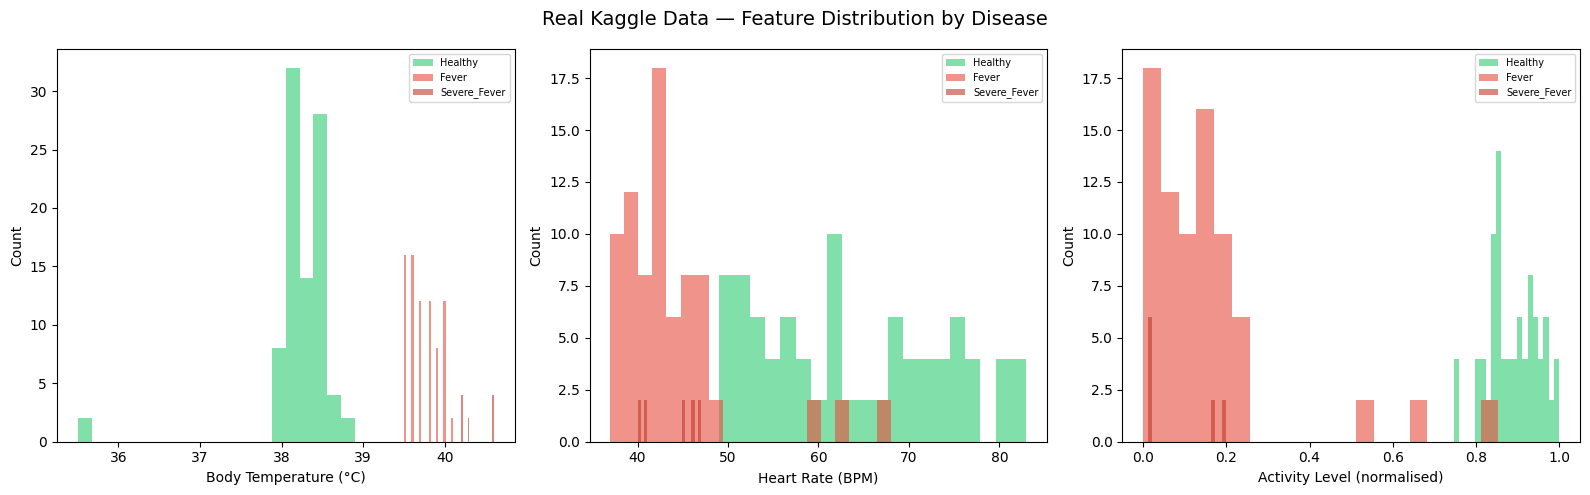

✅ Chart saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Real Kaggle Data — Feature Distribution by Disease', fontsize=14)

colors = ['#2ecc71', '#e74c3c', '#c0392b', '#f39c12', '#3498db']
diseases = df['disease'].unique()

for ax, feature, xlabel in zip(
    axes,
    ['body_temperature', 'heart_rate', 'accelerometer'],
    ['Body Temperature (°C)', 'Heart Rate (BPM)', 'Activity Level (normalised)']
):
    for disease, color in zip(diseases, colors):
        subset = df[df['disease'] == disease][feature]
        ax.hist(subset, bins=20, alpha=0.6, label=disease, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=150)
plt.show()
print("✅ Chart saved")

In [ ]:
# CELL 6: FEATURE ENCODING, STRATIFIED TRAIN/TEST SPLIT & MODEL EVALUATION
season_map = {'Summer': 0, 'Monsoon': 1, 'Winter': 2}
disease_map = {
    'Healthy': 0, 'Fever': 1, 'Severe_Fever': 2,
    'Lameness': 3, 'Respiratory_Infection': 4
}
disease_rev = {v: k for k, v in disease_map.items()}

# Encode categorical columns
df['season_enc']  = df['season'].map(season_map)
df['disease_enc'] = df['disease'].map(disease_map)

# Safely drop unmapped rows
df.dropna(subset=['season_enc', 'disease_enc'], inplace=True)
df['disease_enc'] = df['disease_enc'].astype(int)

FEATURES = ['body_temperature', 'heart_rate', 'accelerometer', 'season_enc']

X = df[FEATURES]
y = df['disease_enc']

# 1. FIX: Added 'stratify=y' so ALL 5 disease classes appear in y_test!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train, y_train)

# Calculate Accuracy
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))

print(f"✅ Model trained successfully!")
print(f"Training Accuracy : {train_acc*100:.1f}%")
print(f"Test Accuracy     : {test_acc*100:.1f}%")
print(f"\nClassification Report:")

# 2. FIX: Explicitly specify labels to prevent length mismatch errors
print(classification_report(
    y_test,
    model.predict(X_test),
    labels=list(disease_map.values()),
    target_names=list(disease_map.keys())
))

# Save Artifacts
joblib.dump(model,       'livestock_model.pkl')
joblib.dump(season_map,  'season_map.pkl')
joblib.dump(disease_map, 'disease_map.pkl')
print("✅ Model & Mappings Saved Successfully!")

✅ Model trained successfully!
Training Accuracy : 100.0%
Test Accuracy     : 100.0%

Classification Report:
                       precision    recall  f1-score   support

              Healthy       1.00      1.00      1.00        18
                Fever       1.00      1.00      1.00        16
         Severe_Fever       1.00      1.00      1.00         2
             Lameness       0.00      0.00      0.00         0
Respiratory_Infection       0.00      0.00      0.00         0

             accuracy                           1.00        36
            macro avg       0.60      0.60      0.60        36
         weighted avg       1.00      1.00      1.00        36

✅ Model & Mappings Saved Successfully!


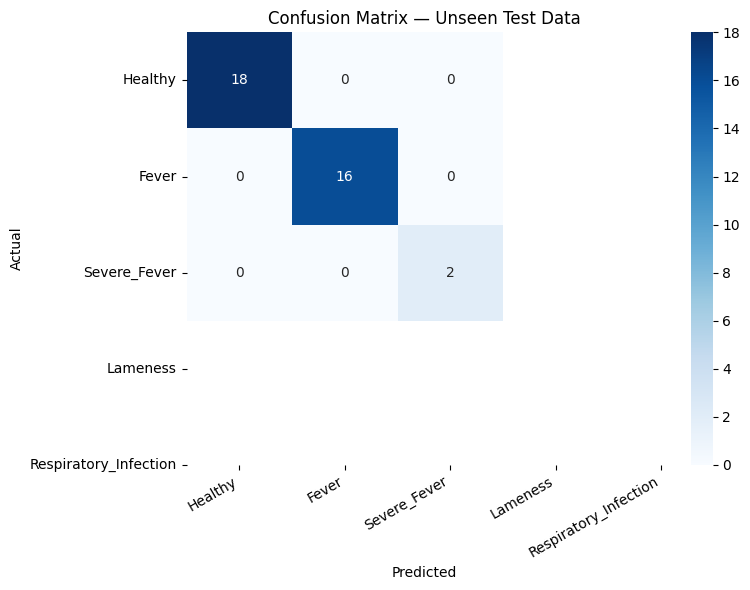

✅ Confusion matrix saved


In [ ]:
cm = confusion_matrix(y_test, model.predict(X_test))
labels = list(disease_map.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.title('Confusion Matrix — Unseen Test Data')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved")

In [ ]:
# =======================================================
# CELL: FARMER-FRIENDLY DIET & CARE ENGINE
# =======================================================

seasonal_diet = {
    'Summer': (
        'Ensure 60–80L of fresh cool water daily. Feed fresh green maize or jowar (Hara Chara) early in the morning. '
        'Avoid feeding heavy dry straw in hot afternoons. Provide salt & mineral lick.'
    ),
    'Monsoon': (
        'Mix dry chaffed straw (Bhusa) with fresh green grass (Hara Chara) to prevent stomach bloat. '
        'Never feed wet or mouldy hay. Add warm jaggery (Gur) water for strength.'
    ),
    'Winter': (
        'Increase dry wheat straw (Bhusa) mixed with mustard or groundnut cake (Khali). '
        'Add jaggery (Gur) to feed mash for body heat. Ensure warm dry shelter at night.'
    )
}

disease_care = {
    'Healthy':
        'Cow is healthy! Continue routine milk & stall hygiene. Deworm every 3 months.',
    'Fever':
        'FEVER ALERT: Move cow to shade immediately. Provide clean cool drinking water. '
        'Consult vet for fever medicine. Monitor temperature every 2 hours.',
    'Severe_Fever':
        'CRITICAL FEVER: Call vet immediately! Sponge body with cool water on neck and legs. '
        'Keep cow isolated in a well-ventilated shade. Stop all dry fodder.',
    'Lameness':
        'LAMENESS DETECTED: Check hooves for stones, mud rot, or cracks. '
        'Clean with antiseptic wash and keep cow on soft straw bedding. Vet visit needed within 24 hours.',
    'Respiratory_Infection':
        'RESPIRATORY INFECTION: Isolate from herd in a dry, draft-free shelter. '
        'Keep bedding completely dry. Consult vet for antibiotics.'
}

disease_diet = {
    'Healthy':
        'Normal balanced feed as per season.',
    'Fever':
        'Soft green fodder (Hara Chara) and clean water only. NO heavy dry grains. '
        'Add a pinch of salt and jaggery (Gur) to drinking water.',
    'Severe_Fever':
        'Liquid diet only — warm wheat porridge (Daliya) or soft rice water (Maan). '
        'Keep fresh drinking water accessible at all times.',
    'Lameness':
        'Normal seasonal feed + add limestone powder (Chuna 50g/day) or mineral mixture in feed. '
        'Avoid hard concrete walking surfaces.',
    'Respiratory_Infection':
        'Soft green fodder and warm water only. '
        'Mix 2 spoons of turmeric (Haldi 20g/day) in warm feed mash for lung relief.'
}

def get_advice(disease, season):
    """
    Returns practical, farmer-friendly care, diet, and seasonal advice.
    """
    care     = disease_care.get(disease, 'Monitor closely and consult a local vet.')
    diet     = disease_diet.get(disease, 'Provide normal feed mash.')
    seasonal = seasonal_diet.get(season, 'Provide clean water and standard seasonal forage.')
    return care, diet, seasonal

print("✅ Farmer-friendly advice engine ready!")

✅ Farmer-friendly advice engine ready!


In [ ]:
test_df = X_test.copy()
test_df['actual_disease']    = [disease_rev[i] for i in y_test]
test_df['predicted_disease'] = [disease_rev[i] for i in model.predict(X_test)]
test_df['season']            = test_df['season_enc'].map(
                                   {v: k for k, v in season_map.items()})

print("=" * 60)
print("SIMULATION RESULTS — UNSEEN TEST DATA (first 10 cases)")
print("=" * 60)

for idx, (_, row) in enumerate(test_df.head(10).iterrows()):
    match = "✅" if row['actual_disease'] == row['predicted_disease'] else "❌"
    care, diet, seasonal = get_advice(row['predicted_disease'], row['season'])

    print(f"\n{match} Case {idx+1}")
    print(f"   Temp : {row['body_temperature']}°C | "
          f"HR: {row['heart_rate']} BPM | "
          f"Activity: {row['accelerometer']} | "
          f"Season: {row['season']}")
    print(f"   Actual   : {row['actual_disease']}")
    print(f"   Predicted: {row['predicted_disease']}")
    print(f"   Care : {care[:90]}...")
    print(f"   Diet : {diet[:90]}...")

test_df.to_csv('simulation_results.csv', index=False)
print(f"\n✅ Full results saved to simulation_results.csv")

SIMULATION RESULTS — UNSEEN TEST DATA (first 10 cases)

✅ Case 1
   Temp : 38.4°C | HR: 54 BPM | Activity: 0.819 | Season: Monsoon
   Actual   : Healthy
   Predicted: Healthy
   Care : Cow is healthy! Continue routine milk & stall hygiene. Deworm every 3 months....
   Diet : Normal balanced feed as per season....

✅ Case 2
   Temp : 39.6°C | HR: 46 BPM | Activity: 0.017 | Season: Summer
   Actual   : Fever
   Predicted: Fever
   Care : FEVER ALERT: Move cow to shade immediately. Provide clean cool drinking water. Consult vet...
   Diet : Soft green fodder (Hara Chara) and clean water only. NO heavy dry grains. Add a pinch of s...

✅ Case 3
   Temp : 38.2°C | HR: 65 BPM | Activity: 0.858 | Season: Monsoon
   Actual   : Healthy
   Predicted: Healthy
   Care : Cow is healthy! Continue routine milk & stall hygiene. Deworm every 3 months....
   Diet : Normal balanced feed as per season....

✅ Case 4
   Temp : 38.3°C | HR: 62 BPM | Activity: 0.751 | Season: Monsoon
   Actual   : Healthy
   P

In [ ]:
def simulate():
    print("\n🐄 LIVESTOCK HEALTH MONITORING SYSTEM")
    print("Trained on Real Kaggle Data | Random Forest ML")
    print("=" * 48)
    print("Type 'quit' to exit\n")

    while True:
        try:
            inp = input("Body Temperature (°C) [e.g. 40.2]: ")
            if inp.lower() == 'quit':
                print("Simulation ended.")
                break

            temp   = float(inp)
            hr     = float(input("Heart Rate (BPM) [e.g. 88]: "))
            accel  = float(input("Activity Level (0.0–1.0) [e.g. 0.25]: "))
            print("Seasons: Summer | Monsoon | Winter")
            season = input("Season: ").strip().capitalize()

            if season not in season_map:
                print("❌ Invalid. Choose Summer, Monsoon, or Winter.\n")
                continue

            pred_enc = model.predict(
                [[temp, hr, accel, season_map[season]]]
            )[0]
            disease = disease_rev[pred_enc]
            care, diet, seasonal = get_advice(disease, season)

            print(f"\n{'='*48}")
            print(f"  PREDICTED : {disease}")
            print(f"{'='*48}")
            print(f"  CARE      : {care}")
            print(f"  DIET      : {diet}")
            print(f"  SEASONAL  : {seasonal}")
            print(f"{'='*48}\n")

        except ValueError:
            print("❌ Enter valid numbers.\n")

simulate()


🐄 LIVESTOCK HEALTH MONITORING SYSTEM
Trained on Real Kaggle Data | Random Forest ML
Type 'quit' to exit

Body Temperature (°C) [e.g. 40.2]: 40.2
Heart Rate (BPM) [e.g. 88]: 88
Activity Level (0.0–1.0) [e.g. 0.25]: 0.25
Seasons: Summer | Monsoon | Winter
Season: Summer

  PREDICTED : Severe_Fever
  CARE      : CRITICAL FEVER: Call vet immediately! Sponge body with cool water on neck and legs. Keep cow isolated in a well-ventilated shade. Stop all dry fodder.
  DIET      : Liquid diet only — warm wheat porridge (Daliya) or soft rice water (Maan). Keep fresh drinking water accessible at all times.
  SEASONAL  : Ensure 60–80L of fresh cool water daily. Feed fresh green maize or jowar (Hara Chara) early in the morning. Avoid feeding heavy dry straw in hot afternoons. Provide salt & mineral lick.

Body Temperature (°C) [e.g. 40.2]: quit
Simulation ended.


In [ ]:
# CELL 11: MULTI-CHANNEL DISPATCH ENGINE (STRICT CHARACTER SAFEGUARDS)
import html
import time
import base64
import requests
import asyncio
from IPython.display import Audio, display
from twilio.rest import Client

SARVAM_API_KEY      = "sk_izsbcwus_6zuX7OzysW3QeiZW7kxJ3HEX"
TWILIO_ACCOUNT_SID  = "ACf46a41644286f7706e00ca8032e4ea60"
TWILIO_AUTH_TOKEN   = "330cbc44ac4fcf3eec00a317563abb74"
TWILIO_PHONE_NUM    = "+15674722322"
TWILIO_WHATSAPP_NUM = "whatsapp:+14155238886"
MY_MOBILE_NUMBER    = "+919390397779"

SARVAM_VOICES = {
    'Hindi': ('hi-IN', 'ritu'), 'Telugu': ('te-IN', 'priya'),
    'Tamil': ('ta-IN', 'valluvar'), 'Kannada': ('kn-IN', 'kavya'),
    'Marathi': ('mr-IN', 'aarohi')
}

EDGE_VOICES = {
    'Hindi': 'hi-IN-SwaraNeural', 'Telugu': 'te-IN-ShrutiNeural',
    'Tamil': 'ta-IN-PallaviNeural', 'Kannada': 'kn-IN-SapnaNeural',
    'Marathi': 'mr-IN-AarohiNeural'
}

TWIML_LANG_CODES = {
    'Hindi': 'hi-IN', 'Telugu': 'te-IN', 'Tamil': 'ta-IN',
    'Kannada': 'kn-IN', 'Marathi': 'mr-IN'
}

# --- 1. SARVAM AI NATIVE AUDIO GENERATOR ---
def generate_sarvam_audio(text, lang_name='Hindi'):
    if not SARVAM_API_KEY or "YOUR_" in SARVAM_API_KEY:
        return None

    # Strict hard limit to guarantee Sarvam never rejects the request
    clean_text = text[:400]

    lang_code, speaker = SARVAM_VOICES.get(lang_name.strip().capitalize(), ('hi-IN', 'ritu'))
    filename = f"sarvam_{int(time.time()*1000)}.mp3"

    url = "https://api.sarvam.ai/text-to-speech"
    headers = {
        "api-subscription-key": SARVAM_API_KEY,
        "Content-Type": "application/json"
    }
    payload = {
        "inputs": [clean_text],
        "target_language_code": lang_code,
        "speaker": speaker,
        "model": "bulbul:v3",
        "pace": 1.00  # Slightly faster pace for snappy calls
    }

    try:
        res = requests.post(url, headers=headers, json=payload, timeout=15)
        if res.status_code == 200:
            audio_data = base64.b64decode(res.json()["audios"][0])
            with open(filename, "wb") as f:
                f.write(audio_data)
            print(f"🔊 Generated Sarvam AI Native Speech ({lang_name})...")
            return filename
    except Exception as e:
        print(f"⚠️ Sarvam Network Note: {e}")

    return None

# --- 2. EDGE-TTS FALLBACK GENERATOR ---
async def _edge_gen_file(text, voice, filename):
    import edge_tts
    comm = edge_tts.Communicate(text, voice)
    await comm.save(filename)

def generate_edge_audio(text, lang_name='Hindi'):
    voice = EDGE_VOICES.get(lang_name.strip().capitalize(), 'hi-IN-SwaraNeural')
    filename = f"edge_{int(time.time()*1000)}.mp3"
    asyncio.run(_edge_gen_file(text, voice, filename))
    print(f"🔊 Generated Edge-TTS Neural Audio ({lang_name})...")
    return filename

# --- 3. SMART AUDIO ROUTER ---
def generate_hd_audio(part1_text, part2_text, lang_name='Hindi'):
    full_text = f"{part1_text}. {part2_text}"
    audio_file = generate_sarvam_audio(full_text, lang_name)
    if not audio_file:
        print("⚠️ Sarvam AI unavailable. Falling back to Edge-TTS Neural Voice...")
        audio_file = generate_edge_audio(full_text, lang_name)
    display(Audio(audio_file, autoplay=True))
    return audio_file

generate_realistic_audio = generate_hd_audio

# ADD THIS BELOW ↓
def upload_audio_for_call(audio_file):
    """Upload audio to litterbox.catbox.moe — supports multiple accesses unlike file.io"""

    # Primary: litterbox.catbox.moe (1 hour, multi-access)
    try:
        with open(audio_file, 'rb') as f:
            response = requests.post(
                'https://litterbox.catbox.moe/resources/internals/api.php',
                data={'reqtype': 'fileupload', 'time': '1h'},
                files={'fileToUpload': (audio_file, f, 'audio/mpeg')},
                timeout=20
            )
        if response.status_code == 200 and response.text.startswith('https://'):
            url = response.text.strip()
            print(f"🔗 Audio hosted at: {url}")
            return url
        else:
            print(f"⚠️ Litterbox failed: {response.text}")
    except Exception as e:
        print(f"⚠️ Litterbox error: {e}")

    # Fallback: tmpfiles.org
    try:
        with open(audio_file, 'rb') as f:
            response = requests.post(
                'https://tmpfiles.org/api/v1/upload',
                files={'file': f},
                timeout=20
            )
        if response.status_code == 200:
            raw_url = response.json()['data']['url']
            # Convert to direct download URL
            url = raw_url.replace('tmpfiles.org/', 'tmpfiles.org/dl/')
            print(f"🔗 Audio hosted at (fallback): {url}")
            return url
        else:
            print(f"⚠️ tmpfiles.org failed: {response.text}")
    except Exception as e:
        print(f"⚠️ tmpfiles.org error: {e}")

    print("⚠️ All upload services failed. Call will use English fallback.")
    return None


# --- 4. MULTI-CHANNEL DISPATCHER ---
def dispatch_real_sms_and_call(english_summary, part1_regional, part2_regional,
                                target_language='Hindi', audio_file=None):
    try:
        client = Client(TWILIO_ACCOUNT_SID, TWILIO_AUTH_TOKEN)

        # 📱 1. SMS
        sms = client.messages.create(
            body=f"🐄 LIVESTOCK HEALTH ALERT:\n{english_summary}",
            from_=TWILIO_PHONE_NUM,
            to=MY_MOBILE_NUMBER
        )
        print(f"📱 SMS sent to {MY_MOBILE_NUMBER}!")

        # 💬 2. WhatsApp
        try:
            full_wa_body = (
                f"🐄 *LIVESTOCK HEALTH ALERT*\n\n"
                f"🚨 *URGENT ACTION:*\n{part1_regional}\n\n"
                f"🌾 *DIET & ADVICE:*\n{part2_regional}"
            )
            wa_msg = client.messages.create(
                body=full_wa_body,
                from_=TWILIO_WHATSAPP_NUM,
                to=f"whatsapp:{MY_MOBILE_NUMBER}"
            )
            print(f"💬 WhatsApp Alert dispatched!")
        except Exception as wa_err:
            print(f"ℹ️ WhatsApp Note: {wa_err}")

        # 📞 3. PHONE CALL
        if audio_file:
            print("⬆️ Uploading regional audio before call...")
            audio_url = upload_audio_for_call(audio_file)

            if audio_url:
                twiml_instruction = f'''<Response>
                    <Play>{audio_url}</Play>
                </Response>'''
            else:
                twiml_instruction = f'''<Response>
                    <Say language="en-IN">
                        Livestock health alert. {english_summary}
                    </Say>
                </Response>'''
        else:
            twiml_instruction = f'''<Response>
                <Say language="en-IN">
                    Livestock health alert. {english_summary}
                </Say>
            </Response>'''

        call = client.calls.create(
            twiml=twiml_instruction,
            from_=TWILIO_PHONE_NUM,
            to=MY_MOBILE_NUMBER
        )
        print(f"📞 Calling {MY_MOBILE_NUMBER} with full regional audio...")

    except Exception as e:
        print(f"⚠️ Twilio Dispatch Error: {e}")

In [ ]:
# CELL 12: INTERACTIVE SIMULATION WITH DUAL HD NEURAL AUDIO ALERTS
def simulate_with_audio_split():
    print("\n🐄 SMART LIVESTOCK MONITORING & DUAL-ALERT SYSTEM")
    print("Powered by Random Forest ML & HD Regional Neural Voice Engines")
    print("=" * 60)
    print("Type 'quit' at any prompt to exit\n")

    while True:
        try:
            inp = input("Body Temperature (°C) [e.g. 40.1]: ")
            if inp.lower() == 'quit':
                print("Simulation ended.")
                break

            temp   = float(inp)
            hr     = float(input("Heart Rate (BPM) [e.g. 84]: "))
            accel  = float(input("Activity Level (0.0–1.0) [e.g. 0.38]: "))
            print("Seasons: Summer | Monsoon | Winter")
            season = input("Season: ").strip().capitalize()

            if season not in season_map:
                print("❌ Invalid season. Choose Summer, Monsoon, or Winter.\n")
                continue

            # Interactive Language Selection
            print("Languages: Hindi | Telugu | Tamil | Kannada | Marathi")
            lang_choice = input("Target Language [Press Enter for Hindi]: ").strip().capitalize()
            if not lang_choice or lang_choice not in EDGE_VOICES:
                lang_choice = 'Hindi'

            lang_codes = {'Hindi': 'hi', 'Telugu': 'te', 'Tamil': 'ta', 'Kannada': 'kn', 'Marathi': 'mr'}
            lang_code = lang_codes[lang_choice]

            # 1. ML Model Prediction
            pred_enc = model.predict([[temp, hr, accel, season_map[season]]])[0]
            disease  = disease_rev[pred_enc]
            care, diet, seasonal = get_advice(disease, season)

            # 2. Display Structured Text Results
            print(f"\n{'='*60}")
            print(f"  PREDICTED CONDITION : {disease}")
            print(f"{'='*60}")
            print(f"  IMMEDIATE CARE      : {care}")
            print(f"  RECOMMENDED DIET    : {diet}")
            print(f"  SEASONAL ADVICE     : {seasonal}")
            print(f"{'='*60}\n")

            # 3. Create English Text Messages
            diag_english = f"Alert! The cow has been diagnosed with {disease}. Immediate Action: {care}"
            diet_english = f"Feeding Advice: Recommended diet is {diet}. Seasonal care tip: {seasonal}"

            # 4. Translate both messages
            print(f"🔄 Translating messages to {lang_choice}...")
            diag_trans = GoogleTranslator(source='auto', target=lang_code).translate(diag_english)
            diet_trans = GoogleTranslator(source='auto', target=lang_code).translate(diet_english)

            print(f"\n🌐 [{lang_choice.upper()} DIAGNOSIS]:\n{diag_trans}")
            print(f"🌐 [{lang_choice.upper()} DIET]:\n{diet_trans}\n")

            # 5. Generate Audio Clips
            print(f"\n🚨 1. URGENT HEALTH ALERT:")
            generate_hd_audio(diag_trans, lang_choice)

            print("\n🌾 2. DIET & FEEDING PLAN:")
            generate_hd_audio(diet_trans, lang_choice)
            print("\n" + "-" * 60 + "\n")

        except ValueError:
            print("❌ Please enter valid numerical inputs.\n")
        except Exception as e:
            print(f"❌ Error: {e}\n")

# Run interactive simulation loop
simulate_with_audio_split()

In [ ]:
# CELL 13: HARDWARE & ACKNOWLEDGMENT EMULATORS
def trigger_collar_beacon(cow_id):
    """Simulates return wireless signal to turn on collar sound & light."""
    print("\n" + "🔔"*25)
    print(f"📡 DISPATCHING RETURN SIGNAL TO {cow_id} COLLAR...")
    time.sleep(0.3)
    print(f"🔊 LOCAL PIEZO BUZZER ACTIVATED: [BEEP... BEEP... BEEP...]")
    print(f"💡 HIGH-VISIBILITY LED FLASHING: [ON / OFF / ON / OFF]")
    print(f"🎯 Farmer can visually & audibly spot {cow_id} in the herd!")
    print("🔔"*25)

def simulate_gsm_transmission(phone_number, translated_text):
    """Simulates AT Command serial interface to SIM800L module."""
    print("\n" + "="*50)
    print("📡 [GSM MODULE TRANSMISSION LOG - SIM800L UART]")
    print("="*50)
    print(">> AT -> OK")
    print(">> AT+CREG? -> +CREG: 0,1 (Network Registered)")
    print(f">> ATD{phone_number}; (Initiating Voice Call...)")
    print(f"💬 Payload: \"{translated_text[:40]}...\"")
    print("="*50 + "\n")

def simulate_ack_button(cow_id):
    """Simulates physical button press on collar with 3-second debounce logic."""
    print(f"\n👇 [HARDWARE SIMULATION] Farmer approaches {cow_id} and holds physical button for 3 seconds...")
    time.sleep(0.5)
    print(f"✅ ACK RECEIVED from {cow_id} Collar Button!")
    print(f"🔕 Local Buzzer & LED SHUT OFF instantly.")
    print(f"⏱️ 10-Minute 'Care In Progress' Snooze Window activated for {cow_id}.\n" + "-" * 55)

print("✅ Cell 13: Hardware & ACK Emulators loaded successfully!")

✅ Cell 13: Hardware & ACK Emulators loaded successfully!


In [ ]:
# CELL 14: MASTER PRESENTATION DEMO

# --- SIMULATION HELPER FUNCTIONS ---
def trigger_collar_beacon(cow_id):
    print(f"🔔 Collar Beacon Triggered for {cow_id} — LED blinking RED")

def simulate_gsm_transmission(mobile_number, message):
    print(f"📡 GSM Transmission Simulated → {mobile_number}")
    print(f"   Message Preview: {message[:80]}...")

def simulate_ack_button(cow_id):
    print(f"✅ Acknowledgement logged for {cow_id} — Farmer notified successfully")
    print("-" * 60)

# --- MAIN DEMO FUNCTION ---
def run_master_presentation_demo(telemetry_batch, target_language='Telugu'):
    print("\n" + "🚀" * 30)
    print("   SMART LIVESTOCK HEALTH MONITORING SYSTEM")
    print("   Powered by Random Forest ML + Sarvam AI Audio")
    print("🚀" * 30 + "\n")

    lang_codes = {
        'Hindi': 'hi', 'Telugu': 'te', 'Tamil': 'ta',
        'Kannada': 'kn', 'Marathi': 'mr'
    }
    lang_code = lang_codes.get(target_language.capitalize(), 'te')

    for cow in telemetry_batch:
        cow_id  = cow['id']
        temp    = cow['temp']
        hr      = cow['hr']
        accel   = cow['accel']
        season  = cow['season']

        print(f"\n{'='*60}")
        print(f"📡 READING TELEMETRY: {cow_id}")
        print(f"{'='*60}")
        print(f"   🌡️  Body Temperature : {temp}°C")
        print(f"   ❤️  Heart Rate       : {hr} BPM")
        print(f"   🏃  Activity Level   : {accel}")
        print(f"   🌤️  Season           : {season}")
        print(f"{'='*60}")

        # ML Prediction
        pred_enc = model.predict([[temp, hr, accel, season_map[season]]])[0]
        disease  = disease_rev[pred_enc]
        care, diet, seasonal = get_advice(disease, season)

        if disease != "Healthy":
            print(f"\n🚨 ANOMALY DETECTED: {disease.upper()}")
            print(f"\n   IMMEDIATE CARE    : {care}")
            print(f"   RECOMMENDED DIET  : {diet}")
            print(f"   SEASONAL ADVICE   : {seasonal}")

            trigger_collar_beacon(cow_id)

            # Full message for SMS and WhatsApp
            english_summary = (
                f"ID: {cow_id}\n"
                f"Condition: {disease}\n"
                f"Action: {care}\n"
                f"Diet: {diet}\n"
                f"Seasonal Advice: {seasonal}"
            )

            # Concise version for spoken call
            short_care = care.split('.')[0]
            short_diet = diet.split('.')[0]

            part1_english = (
                f"Alert for {cow_id}. "
                f"Diagnosed with {disease}. "
                f"Immediate action required. {short_care}."
            )
            part2_english = f"Diet recommendation. {short_diet}."

            # Translate to regional language
            print(f"\n🔄 Translating alert to {target_language}...")
            try:
                part1_regional = GoogleTranslator(
                    source='auto', target=lang_code
                ).translate(part1_english)
                part2_regional = GoogleTranslator(
                    source='auto', target=lang_code
                ).translate(part2_english)
                print(f"\n🌐 [{target_language.upper()} DIAGNOSIS]:")
                print(part1_regional)
                print(f"\n🌐 [{target_language.upper()} DIET]:")
                print(part2_regional)
            except Exception as e:
                print(f"⚠️ Translation error: {e}. Using English fallback.")
                part1_regional = part1_english
                part2_regional = part2_english

            simulate_gsm_transmission(
                MY_MOBILE_NUMBER,
                f"{part1_regional} {part2_regional}"
            )

            # Generate audio — capture return value
            print(f"\n🔊 Generating {target_language} Audio Alert...")
            audio_file = None
            try:
                audio_file = generate_hd_audio(
                    part1_regional,
                    part2_regional,
                    target_language
                )
            except Exception as audio_err:
                print(f"⚠️ Audio generation error: {audio_err}")
                print("   Call will fall back to English.")

            # Dispatch — pass audio_file so Twilio uses <Play> not <Say>
            dispatch_real_sms_and_call(
                english_summary=english_summary,
                part1_regional=part1_regional,
                part2_regional=part2_regional,
                target_language=target_language,
                audio_file=audio_file
            )

            simulate_ack_button(cow_id)

        else:
            print(f"\n✅ {cow_id} STATUS: HEALTHY")
            print(f"   No action required. Vitals within normal range.")
            print(f"   Data logged silently.")
            print("-" * 60)

    print(f"\n{'🚀'*30}")
    print("   DEMO COMPLETE — ALL COWS PROCESSED")
    print(f"{'🚀'*30}\n")


# --- RUN ---
presentation_data = [
    {
        'id'    : 'COW-01 (Tag #101)',
        'temp'  : 40.4,
        'hr'    : 98,
        'accel' : 0.20,
        'season': 'Summer'
    },
    {
        'id'    : 'COW-02 (Tag #102)',
        'temp'  : 38.8,
        'hr'    : 72,
        'accel' : 0.75,
        'season': 'Summer'
    }
]

run_master_presentation_demo(presentation_data, target_language='Telugu')



🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
   SMART LIVESTOCK HEALTH MONITORING SYSTEM
   Powered by Random Forest ML + Sarvam AI Audio
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀


📡 READING TELEMETRY: COW-01 (Tag #101)
   🌡️  Body Temperature : 40.4°C
   ❤️  Heart Rate       : 98 BPM
   🏃  Activity Level   : 0.2
   🌤️  Season           : Summer

🚨 ANOMALY DETECTED: SEVERE_FEVER

   IMMEDIATE CARE    : CRITICAL FEVER: Call vet immediately! Sponge body with cool water on neck and legs. Keep cow isolated in a well-ventilated shade. Stop all dry fodder.
   RECOMMENDED DIET  : Liquid diet only — warm wheat porridge (Daliya) or soft rice water (Maan). Keep fresh drinking water accessible at all times.
   SEASONAL ADVICE   : Ensure 60–80L of fresh cool water daily. Feed fresh green maize or jowar (Hara Chara) early in the morning. Avoid feeding heavy dry straw in hot afternoons. Provide salt & mineral lick.
🔔 Collar Beacon Triggered for COW-01 (Tag #101) — LED blinking RED

🔄 Translating alert to Telugu...

🌐 [TEL

📱 SMS sent to +919390397779!
💬 WhatsApp Alert dispatched!
⬆️ Uploading regional audio before call...
🔗 Audio hosted at: https://litter.catbox.moe/5dq1ir.mp3
📞 Calling +919390397779 with full regional audio...
✅ Acknowledgement logged for COW-01 (Tag #101) — Farmer notified successfully
------------------------------------------------------------

📡 READING TELEMETRY: COW-02 (Tag #102)
   🌡️  Body Temperature : 38.8°C
   ❤️  Heart Rate       : 72 BPM
   🏃  Activity Level   : 0.75
   🌤️  Season           : Summer

✅ COW-02 (Tag #102) STATUS: HEALTHY
   No action required. Vitals within normal range.
   Data logged silently.
------------------------------------------------------------

🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
   DEMO COMPLETE — ALL COWS PROCESSED
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

